# IT325 Machine Learning | Lecture Activity 2
## EDA Planning for the Performance Innovative Task

**Student:** John Michael Angelo Binonggo  
**Dataset:** Asthma Disease Dataset (`asthma_disease_data.csv`)  
**Date:** April 23, 2026

---
This notebook answers all guide questions for Lab Activity 2, covering dataset inspection, target variable identification, data quality assessment, and the planned EDA steps.

## Setup: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

# Load dataset
df = pd.read_csv('asthma_disease_data.csv')
print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 2392 rows x 29 columns


---
## Question 1 “ What is the title or source of your dataset?

In [2]:
print("""
Dataset Title  : Asthma Disease Dataset
File Name      : asthma_disease_data.csv
Source         : Kaggle  “ Asthma Disease Dataset
                 (https://www.kaggle.com/datasets/rabieelkharoua/asthma-disease-dataset)
Author         : Rabie El Kharoua
Description    : A comprehensive synthetic dataset containing patient demographic,
                 lifestyle, environmental exposure, allergy history, lung function,
                 and clinical symptom data used to study asthma diagnosis patterns.
""")


Dataset Title  : Asthma Disease Dataset
File Name      : asthma_disease_data.csv
Source         : Kaggle  “ Asthma Disease Dataset
                 (https://www.kaggle.com/datasets/rabieelkharoua/asthma-disease-dataset)
Author         : Rabie El Kharoua
Description    : A comprehensive synthetic dataset containing patient demographic,
                 lifestyle, environmental exposure, allergy history, lung function,
                 and clinical symptom data used to study asthma diagnosis patterns.



---
## Question 2 “ What real-world problem does your dataset help solve?

In [3]:
print("""
Real-World Problem:
-------------------
Asthma is a chronic respiratory disease affecting millions of people worldwide.
Early and accurate diagnosis is critical to prevent severe attacks and long-term
lung damage, yet many cases remain undetected due to limited access to specialists.

This dataset supports the development of a machine learning classification model
that can PREDICT WHETHER A PATIENT HAS ASTHMA (Diagnosis = 1) OR NOT (Diagnosis = 0)
based on:
  - Demographic factors (Age, Gender, Ethnicity, Education)
  - Lifestyle factors (BMI, Smoking, Physical Activity, Diet, Sleep)
  - Environmental exposures (Pollution, Pollen, Dust)
  - Medical history (Allergies, Eczema, Hay Fever, Reflux)
  - Lung function measurements (FEV1, FVC)
  - Clinical symptoms (Wheezing, Shortness of Breath, Chest Tightness, etc.)

Such a model could assist healthcare providers in screening patients who may not
yet have access to pulmonary function testing, enabling earlier intervention.
""")


Real-World Problem:
-------------------
Asthma is a chronic respiratory disease affecting millions of people worldwide.
Early and accurate diagnosis is critical to prevent severe attacks and long-term
lung damage, yet many cases remain undetected due to limited access to specialists.

This dataset supports the development of a machine learning classification model
that can PREDICT WHETHER A PATIENT HAS ASTHMA (Diagnosis = 1) OR NOT (Diagnosis = 0)
based on:
  - Demographic factors (Age, Gender, Ethnicity, Education)
  - Lifestyle factors (BMI, Smoking, Physical Activity, Diet, Sleep)
  - Environmental exposures (Pollution, Pollen, Dust)
  - Medical history (Allergies, Eczema, Hay Fever, Reflux)
  - Lung function measurements (FEV1, FVC)
  - Clinical symptoms (Wheezing, Shortness of Breath, Chest Tightness, etc.)

Such a model could assist healthcare providers in screening patients who may not
yet have access to pulmonary function testing, enabling earlier intervention.



---
## Question 3 “ Which column contains the text data?

In [4]:
# Check data types to identify the nature of each column
print('Column Data Types:')
print(df.dtypes)
print()

# Identify object/string columns
text_cols = df.select_dtypes(include='object').columns.tolist()
print(f'String/Object columns: {text_cols}')
print()

# Preview those columns
for col in text_cols:
    print(f'  {col} unique values:', df[col].unique()[:5])

Column Data Types:
PatientID                   int64
Age                         int64
Gender                      int64
Ethnicity                   int64
EducationLevel              int64
BMI                       float64
Smoking                     int64
PhysicalActivity          float64
DietQuality               float64
SleepQuality              float64
PollutionExposure         float64
PollenExposure            float64
DustExposure              float64
PetAllergy                  int64
FamilyHistoryAsthma         int64
HistoryOfAllergies          int64
Eczema                      int64
HayFever                    int64
GastroesophagealReflux      int64
LungFunctionFEV1          float64
LungFunctionFVC           float64
Wheezing                    int64
ShortnessOfBreath           int64
ChestTightness              int64
Coughing                    int64
NighttimeSymptoms           int64
ExerciseInduced             int64
Diagnosis                   int64
DoctorInCharge             ob

In [5]:
print("""
NOTE on 'Text' Column:
----------------------
This dataset is a STRUCTURED / TABULAR dataset  ” not a text classification dataset
in the traditional NLP sense. It does not contain a raw natural language text column
(e.g., patient notes or descriptions).

The only non-numeric column is 'DoctorInCharge', which contains doctor identifier
labels (e.g., 'Dr_Confid'). This column carries no diagnostic value and will be
DROPPED before model training.

For this PIT, the 'features' used for classification are ALL numeric columns
(continuous, binary, and encoded categorical), and the prediction target is
the binary column 'Diagnosis'.
""")


NOTE on 'Text' Column:
----------------------
This dataset is a STRUCTURED / TABULAR dataset  ” not a text classification dataset
in the traditional NLP sense. It does not contain a raw natural language text column
(e.g., patient notes or descriptions).

The only non-numeric column is 'DoctorInCharge', which contains doctor identifier
labels (e.g., 'Dr_Confid'). This column carries no diagnostic value and will be
DROPPED before model training.

For this PIT, the 'features' used for classification are ALL numeric columns
(continuous, binary, and encoded categorical), and the prediction target is
the binary column 'Diagnosis'.



---
## Question 4 “ What is your target variable?

In [6]:
target = 'Diagnosis'
print(f'Target Variable : {target}')
print(f'Data Type       : {df[target].dtype}')
print(f'Unique Values   : {sorted(df[target].unique())}')
print()
print('Value Counts:')
print(df[target].value_counts())
print()
print('Class Distribution (%):')
print(df[target].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print()
print('Meaning: 0 = No Asthma Diagnosis,  1 = Asthma Diagnosed')

Target Variable : Diagnosis
Data Type       : int64
Unique Values   : [np.int64(0), np.int64(1)]

Value Counts:
Diagnosis
0    2268
1     124
Name: count, dtype: int64

Class Distribution (%):
Diagnosis
0    94.82%
1     5.18%
Name: proportion, dtype: object

Meaning: 0 = No Asthma Diagnosis,  1 = Asthma Diagnosed


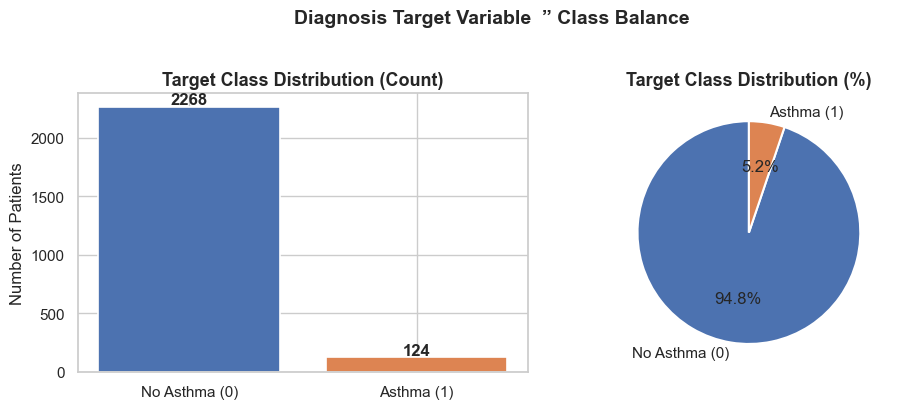


Observation: The dataset is HEAVILY IMBALANCED.
94.8% of patients have no asthma (class 0); only 5.2% are diagnosed (class 1).
This imbalance must be addressed during model training (e.g., SMOTE, class weights).


In [7]:
# Visualize target class distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df[target].value_counts()
labels = ['No Asthma (0)', 'Asthma (1)']
colors = ['#4C72B0', '#DD8452']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Target Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Diagnosis Target Variable  ” Class Balance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nObservation: The dataset is HEAVILY IMBALANCED.')
print('94.8% of patients have no asthma (class 0); only 5.2% are diagnosed (class 1).')
print('This imbalance must be addressed during model training (e.g., SMOTE, class weights).')

---
## Question 5 “ How many rows and columns are in the dataset?

In [8]:
rows, cols = df.shape
print(f'Total Rows    : {rows} (patients)')
print(f'Total Columns : {cols} (features + target + ID + doctor)')
print()
print('Column Breakdown:')
print(f'  - Identifier column        : 1  (PatientID)')
print(f'  - Administrative column    : 1  (DoctorInCharge)')
print(f'  - Target column            : 1  (Diagnosis)')
print(f'  - Feature columns (usable) : {cols - 3}  (all other numeric columns)')
print()
print('Preview of first 5 rows:')
df.head()

Total Rows    : 2392 (patients)
Total Columns : 29 (features + target + ID + doctor)

Column Breakdown:
  - Identifier column        : 1  (PatientID)
  - Administrative column    : 1  (DoctorInCharge)
  - Target column            : 1  (Diagnosis)
  - Feature columns (usable) : 26  (all other numeric columns)

Preview of first 5 rows:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,PollenExposure,DustExposure,PetAllergy,FamilyHistoryAsthma,HistoryOfAllergies,Eczema,HayFever,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,7.388481,2.855578,0.974339,1,1,0,0,0,0,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,1.969838,7.457665,6.584631,0,0,1,0,0,0,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,1.460593,1.448189,5.445799,0,1,1,0,1,0,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,0.581905,7.571845,3.965316,0,0,0,0,1,0,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,0.980875,3.049807,8.260605,0,0,0,0,1,0,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid


In [9]:
# Summary statistics of all numeric columns
print('Statistical Summary:')
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
PatientID,2392.0,6229.500000,690.655244,5034.000000,5631.750000,6229.500000,6827.250000,7425.000000
Age,2392.0,42.137960,21.606655,5.000000,23.000000,42.000000,61.000000,79.000000
Gender,2392.0,0.493311,0.500060,0.000000,0.000000,0.000000,1.000000,1.000000
Ethnicity,2392.0,0.669732,0.986120,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2392.0,1.307274,0.898242,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2392.0,27.244877,7.201628,15.031803,20.968313,27.052202,33.555903,39.985611
Smoking,2392.0,0.141722,0.348838,0.000000,0.000000,0.000000,0.000000,1.000000
PhysicalActivity,2392.0,5.051786,2.903574,0.001740,2.578333,5.016881,7.540234,9.995809
DietQuality,2392.0,5.022867,2.909980,0.003031,2.432043,5.115383,7.544216,9.999904
SleepQuality,2392.0,7.019012,1.732475,4.001437,5.498500,6.975839,8.526950,9.996235


---
## Question 6 “ Are there missing values, duplicates, or columns that may not be useful?

In [10]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found. Dataset is complete.')
print()

print('=== DUPLICATE ROWS ===')
dups = df.duplicated().sum()
print(f'Number of exact duplicate rows: {dups}')
print('No duplicate rows found.' if dups == 0 else f'WARNING: {dups} duplicates detected.')
print()

print('=== COLUMNS THAT MAY NOT BE USEFUL ===')
useless = {
    'PatientID'      : 'Unique patient identifier  ” no predictive value, will be dropped.',
    'DoctorInCharge' : 'Administrative label (all values = "Dr_Confid")  ” no predictive value, will be dropped.',
}
for col, reason in useless.items():
    print(f'  [{col}]: {reason}')

=== MISSING VALUES ===
No missing values found. Dataset is complete.

=== DUPLICATE ROWS ===
Number of exact duplicate rows: 0
No duplicate rows found.

=== COLUMNS THAT MAY NOT BE USEFUL ===
  [PatientID]: Unique patient identifier  ” no predictive value, will be dropped.
  [DoctorInCharge]: Administrative label (all values = "Dr_Confid")  ” no predictive value, will be dropped.


In [11]:
# Confirm DoctorInCharge has only one unique value
print('DoctorInCharge unique values:', df['DoctorInCharge'].unique())
print('PatientID is unique:', df['PatientID'].nunique() == len(df))

DoctorInCharge unique values: ['Dr_Confid']
PatientID is unique: True


In [12]:
# Check for near-constant or low-variance columns
print('=== LOW-VARIANCE CHECK (binary columns) ===')
binary_cols = [c for c in df.columns if df[c].nunique() == 2]
print(f'Binary columns ({len(binary_cols)}): {binary_cols}')
print()
for col in binary_cols:
    dist = df[col].value_counts(normalize=True).mul(100).round(1)
    print(f'  {col}: {dist.to_dict()}')

=== LOW-VARIANCE CHECK (binary columns) ===
Binary columns (15): ['Gender', 'Smoking', 'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever', 'GastroesophagealReflux', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis']

  Gender: {0: 50.7, 1: 49.3}
  Smoking: {0: 85.8, 1: 14.2}
  PetAllergy: {0: 83.4, 1: 16.6}
  FamilyHistoryAsthma: {0: 69.9, 1: 30.1}
  HistoryOfAllergies: {0: 60.1, 1: 39.9}
  Eczema: {0: 80.8, 1: 19.2}
  HayFever: {0: 74.7, 1: 25.3}
  GastroesophagealReflux: {0: 84.2, 1: 15.8}
  Wheezing: {1: 59.6, 0: 40.4}
  ShortnessOfBreath: {1: 50.0, 0: 50.0}
  ChestTightness: {1: 50.3, 0: 49.7}
  Coughing: {1: 50.3, 0: 49.7}
  NighttimeSymptoms: {1: 60.2, 0: 39.8}
  ExerciseInduced: {1: 60.5, 0: 39.5}
  Diagnosis: {0: 94.8, 1: 5.2}


---
## Question 7 “ What EDA steps will you perform before training models?

In [13]:
print("""
PLANNED EDA STEPS BEFORE MODEL TRAINING
=========================================

STEP 1  ” Drop irrelevant columns
  - Remove 'PatientID' (unique ID, no predictive power)
  - Remove 'DoctorInCharge' (single-value string, no predictive power)

STEP 2  ” Inspect target variable distribution
  - Visualize class imbalance (Done: 94.8% vs 5.2%)
  - Plan resampling strategy (SMOTE or class_weight='balanced')

STEP 3  ” Univariate analysis of continuous features
  - Histograms for: Age, BMI, PhysicalActivity, DietQuality, SleepQuality,
    PollutionExposure, PollenExposure, DustExposure, LungFunctionFEV1, LungFunctionFVC
  - Check for skewness and outliers using boxplots

STEP 4  ” Univariate analysis of binary/categorical features
  - Bar charts for: Gender, Smoking, PetAllergy, FamilyHistoryAsthma,
    HistoryOfAllergies, Eczema, HayFever, GastroesophagealReflux,
    Wheezing, ShortnessOfBreath, ChestTightness, Coughing,
    NighttimeSymptoms, ExerciseInduced

STEP 5  ” Bivariate analysis (features vs Diagnosis)
  - Boxplots: compare distributions of continuous features across Diagnosis classes
  - Grouped bar charts: proportions of binary features per Diagnosis class
  - Identify features with strongest visual separation between classes

STEP 6  ” Correlation analysis
  - Compute and visualize a correlation heatmap of all numeric features
  - Identify features most correlated with 'Diagnosis'
  - Detect multi-collinearity between independent features

STEP 7  ” Outlier detection
  - Use IQR method or Z-score on continuous columns
  - Decide whether to cap, transform, or keep outliers

STEP 8  ” Feature scaling assessment
  - Determine which features need normalization (MinMaxScaler)
    or standardization (StandardScaler) before training

STEP 9  ” Feature importance preview
  - Use a quick RandomForest or mutual_info_classif to rank features
  - Use this ranking to guide feature selection in the modeling phase

STEP 10  ” Document findings and finalize cleaned dataset
  - Drop 'PatientID' and 'DoctorInCharge'
  - Save the clean feature matrix (X) and target vector (y)
  - Prepare train/test split strategy
""")


PLANNED EDA STEPS BEFORE MODEL TRAINING

STEP 1  ” Drop irrelevant columns
  - Remove 'PatientID' (unique ID, no predictive power)
  - Remove 'DoctorInCharge' (single-value string, no predictive power)

STEP 2  ” Inspect target variable distribution
  - Visualize class imbalance (Done: 94.8% vs 5.2%)
  - Plan resampling strategy (SMOTE or class_weight='balanced')

STEP 3  ” Univariate analysis of continuous features
  - Histograms for: Age, BMI, PhysicalActivity, DietQuality, SleepQuality,
    PollutionExposure, PollenExposure, DustExposure, LungFunctionFEV1, LungFunctionFVC
  - Check for skewness and outliers using boxplots

STEP 4  ” Univariate analysis of binary/categorical features
  - Bar charts for: Gender, Smoking, PetAllergy, FamilyHistoryAsthma,
    HistoryOfAllergies, Eczema, HayFever, GastroesophagealReflux,
    Wheezing, ShortnessOfBreath, ChestTightness, Coughing,
    NighttimeSymptoms, ExerciseInduced

STEP 5  ” Bivariate analysis (features vs Diagnosis)
  - Boxplots: co

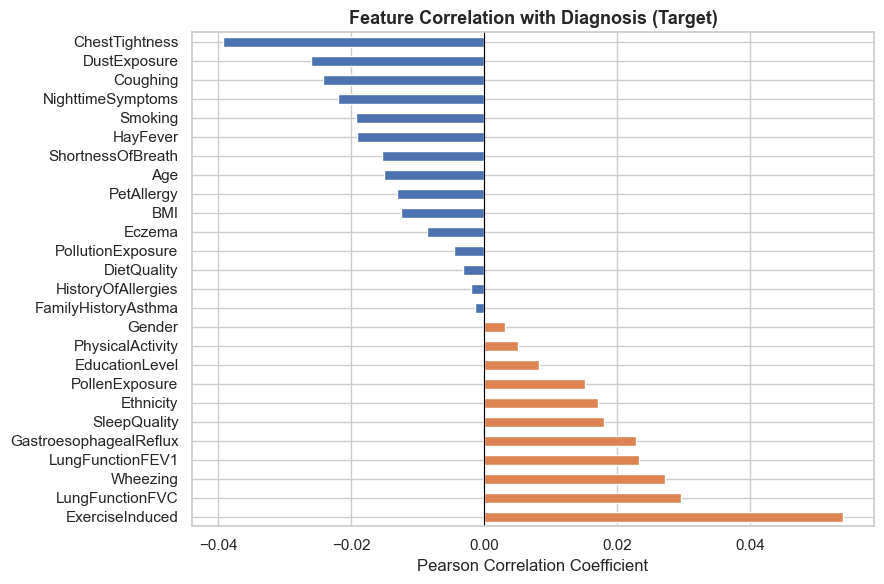

Top positively correlated features (likely asthma indicators):
ExerciseInduced           0.053956
LungFunctionFVC           0.029629
Wheezing                  0.027197
LungFunctionFEV1          0.023336
GastroesophagealReflux    0.022770


In [14]:
# Preview: Correlation heatmap (EDA Step 6 preview)
df_model = df.drop(columns=['PatientID', 'DoctorInCharge'])

corr = df_model.corr()
target_corr = corr['Diagnosis'].drop('Diagnosis').sort_values(ascending=False)

plt.figure(figsize=(9, 6))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Diagnosis (Target)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top positively correlated features (likely asthma indicators):')
print(target_corr.head(5).to_string())

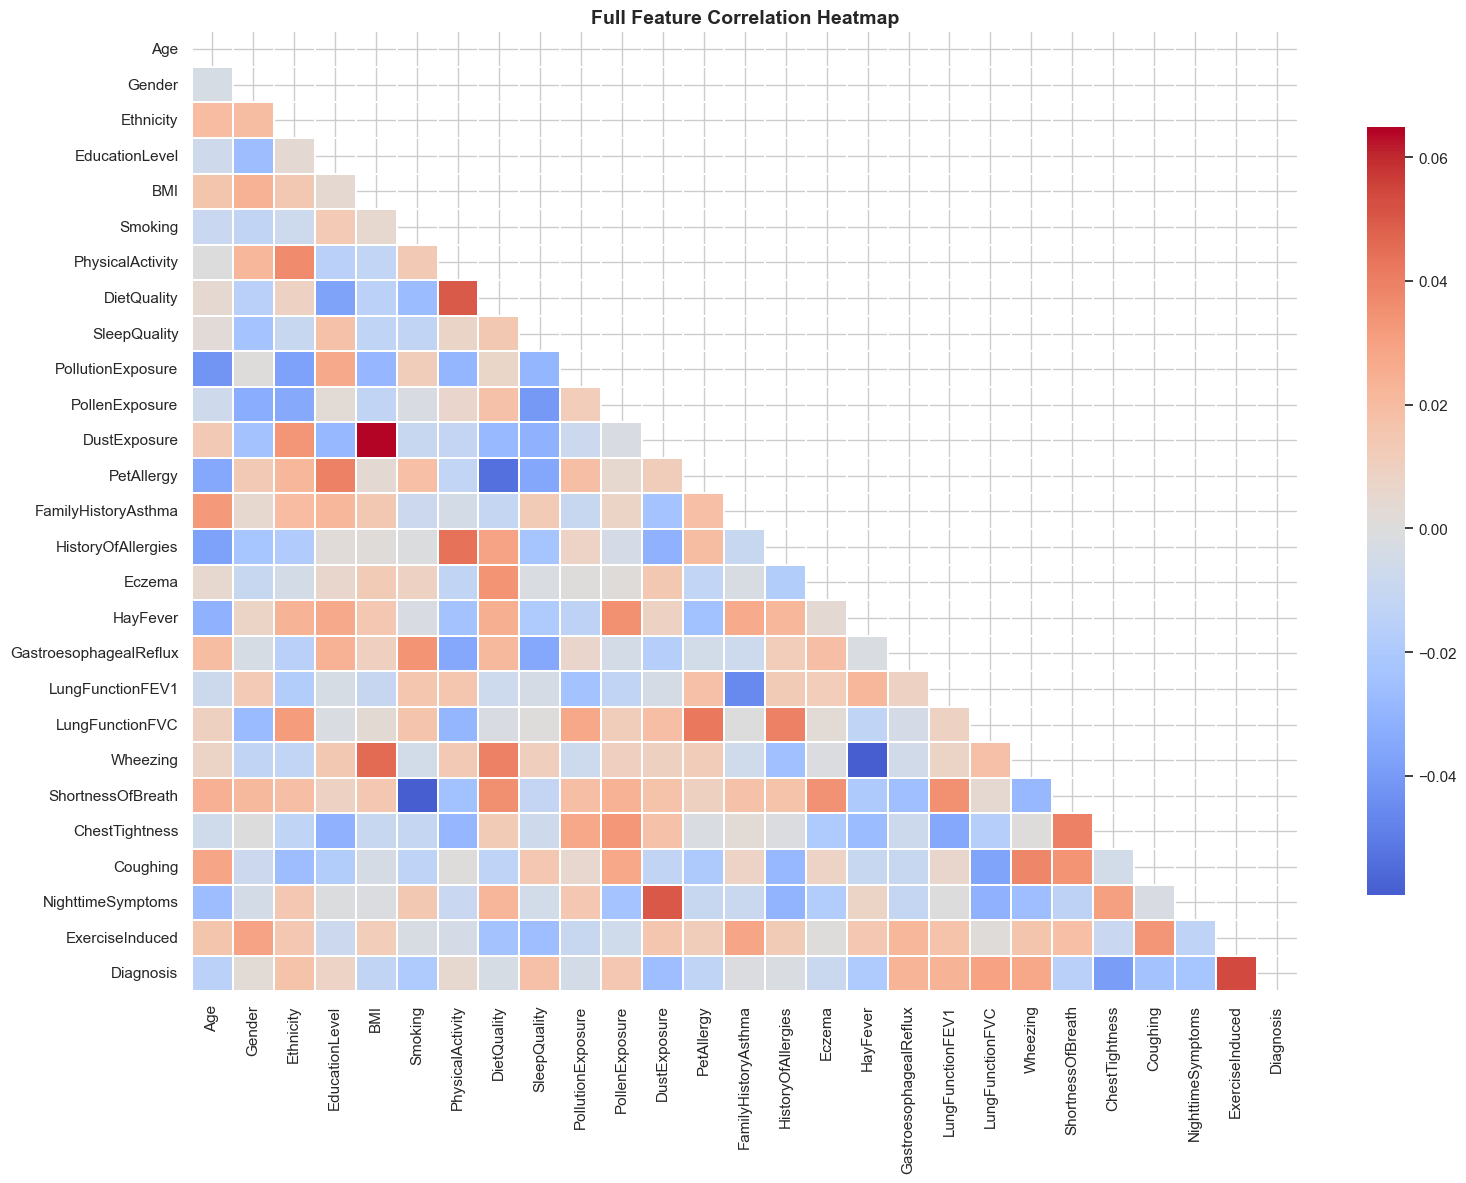

In [15]:
# Full correlation heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Full Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('full_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Comparison: Model Performance and Dataset Summary

This section loads the saved model comparison results and presents a concise
comparison of classifier performance (for Question 4) and a dataset summary
(for Question 5) to help interpret model metrics in context.

Model comparison file loaded: model_comparison_results.csv


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.569937,0.058537,0.48,0.104348,0.580969
1,Decision Tree,0.747390,0.047170,0.20,0.076336,0.480881
2,Random Forest,0.945720,0.333333,0.04,0.071429,0.576564
3,Support Vector Machine,0.910230,0.000000,0.00,0.000000,0.518326
4,Gradient Boosting,0.945720,0.000000,0.00,0.000000,0.563700


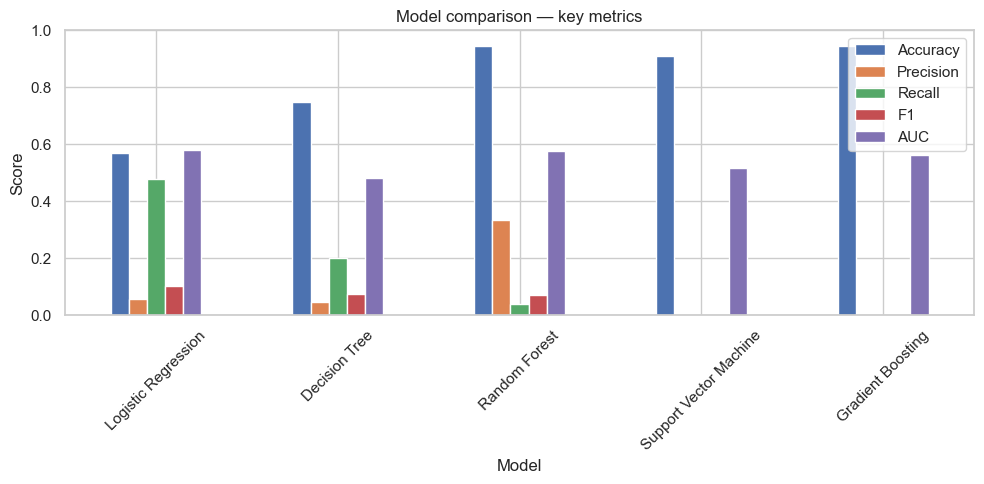

Best model by F1: Logistic Regression (F1=0.104)


In [16]:
# Load and display model comparison results (Question 4)
import os
mc_path = 'model_comparison_results.csv'
if os.path.exists(mc_path):
  mc = pd.read_csv(mc_path)
  print('Model comparison file loaded:', mc_path)
  display(mc)

  # Normalize common metric column names if they exist in the file
  rename_map = {}
  if 'F1-Score' in mc.columns:
      rename_map['F1-Score'] = 'F1'
  if 'ROC-AUC' in mc.columns:
      rename_map['ROC-AUC'] = 'AUC'
  if rename_map:
      mc = mc.rename(columns=rename_map)

  # Common metric columns to plot
  plot_cols = [c for c in ['Accuracy','Precision','Recall','F1','AUC'] if c in mc.columns]
  if plot_cols and 'Model' in mc.columns:
      mc_plot = mc.set_index('Model')[plot_cols]
      ax = mc_plot.plot(kind='bar', figsize=(10,5), rot=45)
      ax.set_ylim(0, 1)
      ax.set_ylabel('Score')
      ax.set_title('Model comparison — key metrics')
      plt.tight_layout()
      plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
      plt.show()
  else:
      print('No standard metric columns found for plotting. Columns:', mc.columns.tolist())

  # Choose preferred metric for selecting the best model
  for metric in ['F1','AUC','Recall','Precision','Accuracy']:
      if metric in mc.columns:
          best_idx = mc[metric].idxmax()
          best = mc.loc[best_idx]
          print(f"Best model by {metric}: {best['Model']} ({metric}={best[metric]:.3f})")
          break
else:
  print('No model comparison CSV found at', mc_path)

In [17]:
# Dataset summary and linking to model interpretation (Question 5)
rows, cols = df.shape
print(f'Total rows    : {rows} (patients)')
print(f'Total columns : {cols} (features + target + ID + doctor)')
print()
print('Class distribution (%):')
print(df['Diagnosis'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print()
print('Usable feature columns (after dropping PatientID and DoctorInCharge):')
usable_cols = [c for c in df.columns if c not in ['PatientID','DoctorInCharge']]
print(len(usable_cols)-1, 'features (excluding target)')
print()
if 'best' in globals():
  print('Top model selected from comparison:')
  print(best.to_string())
  print('\nInterpretation:')
  print('  - Use recall/F1 for the positive (asthma) class when prioritizing detection of patients.')
else:
  print('No best-model information available to link with dataset summary.')

Total rows    : 2392 (patients)
Total columns : 29 (features + target + ID + doctor)

Class distribution (%):
Diagnosis
0    94.82%
1     5.18%
Name: proportion, dtype: object

Usable feature columns (after dropping PatientID and DoctorInCharge):
26 features (excluding target)

Top model selected from comparison:
Model        Logistic Regression
Accuracy                0.569937
Precision               0.058537
Recall                      0.48
F1                      0.104348
AUC                     0.580969

Interpretation:
  - Use recall/F1 for the positive (asthma) class when prioritizing detection of patients.


---
## EDA Planning Summary Sheet

| Item | Detail |
|------|--------|
| **Dataset Title** | Asthma Disease Dataset |
| **Source** | Kaggle (Rabie El Kharoua) |
| **Rows** | 2,392 patients |
| **Columns** | 29 total (26 features + 1 target + 2 drop) |
| **Feature Type** | Numeric tabular (continuous + binary) |
| **Target Variable** | `Diagnosis` (0 = No Asthma, 1 = Asthma) |
| **Missing Values** | None |
| **Duplicate Rows** | None |
| **Columns to Drop** | `PatientID`, `DoctorInCharge` |
| **Class Imbalance** | 94.8% class 0 vs 5.2% class 1  " SMOTE needed |
| **Real-World Problem** | Asthma diagnosis prediction from patient data |
| **EDA Steps Planned** | 10 steps (see Question 7) |